In [1]:
# Load the TensorBoard notebook extension.
%load_ext tensorboard

In [2]:
# Clear any logs from previous runs
!rm -rf ./logs/

In [3]:
from datetime import datetime
from packaging import version

import tensorflow as tf
from tensorflow import keras
# tf.debugging.experimental.enable_dump_debug_info('./logs/',
#                                                  tensor_debug_mode="FULL_HEALTH", 
#                                                  circular_buffer_size=-1)
from keras import backend as K
import numpy as np

print("TensorFlow version: ", tf.__version__)
assert version.parse(tf.__version__).release[0] >= 2, \
    "This notebook requires TensorFlow 2.0 or above."

/Users/nishitha/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version:  2.15.0


In [5]:
data_size = 1000
# 80% of the data is for training.
train_pct = 0.8

train_size = int(data_size * train_pct)

# Create some input data between -1 and 1 and randomize it.
x = np.linspace(-1, 1, data_size)
np.random.shuffle(x)

# Generate the output data.
# y = 0.5x + 2 + noise
y = 0.5 * x + 2 + 0.3 * np.sin(3 * x) + np.random.normal(0, 0.05, (data_size,))

# Split into test and train pairs.
x_train, y_train = x[:train_size], y[:train_size]
x_test, y_test = x[train_size:], y[train_size:]

In [6]:
logdir = "logs/scalars/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=logdir)

model = keras.models.Sequential([
    keras.layers.Dense(16, input_dim=1, activation='relu'),
    keras.layers.Dense(1),
])

model.compile(
    loss='mse', # keras.losses.mean_squared_error
    optimizer=keras.optimizers.SGD(learning_rate=0.2),
)

print("Training ... non-linear data, this takes less than 10 seconds.")
training_history = model.fit(
    x_train, # input
    y_train, # output
    batch_size=train_size,
    verbose=1, # Suppress chatty output; use Tensorboard instead
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[tensorboard_callback],
)

print("Average test loss: ", np.average(training_history.history['loss']))

2025-11-17 21:56:53.260118: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-11-17 21:56:53.260243: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-17 21:56:53.260270: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-11-17 21:56:53.260957: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-17 21:56:53.261026: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Training ... non-linear data, this takes less than 10 seconds.
Epoch 1/20


2025-11-17 21:56:55.908723: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-11-17 21:56:56.019479: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


1/1 [==============================] - 6s 6s/step - loss: 4.0847 - val_loss: 0.2623
Epoch 2/20
1/1 [==============================] - 0s 349ms/step - loss: 0.2523 - val_loss: 0.0274
Epoch 3/20
1/1 [==============================] - 0s 221ms/step - loss: 0.0272 - val_loss: 0.0193
Epoch 4/20
1/1 [==============================] - 0s 282ms/step - loss: 0.0200 - val_loss: 0.0177
Epoch 5/20
1/1 [==============================] - 0s 145ms/step - loss: 0.0184 - val_loss: 0.0171
Epoch 6/20
1/1 [==============================] - 0s 166ms/step - loss: 0.0179 - val_loss: 0.0169
Epoch 7/20
1/1 [==============================] - 0s 127ms/step - loss: 0.0177 - val_loss: 0.0167
Epoch 8/20
1/1 [==============================] - 0s 176ms/step - loss: 0.0176 - val_loss: 0.0167
Epoch 9/20
1/1 [==============================] - 0s 253ms/step - loss: 0.0176 - val_loss: 0.0167
Epoch 10/20
1/1 [==============================] - 1s 524ms/step - loss: 0.0176 - val_loss: 0.0167
Epoch 11/20
1/1 [================

7/7 [==============================] - 2s 155ms/step


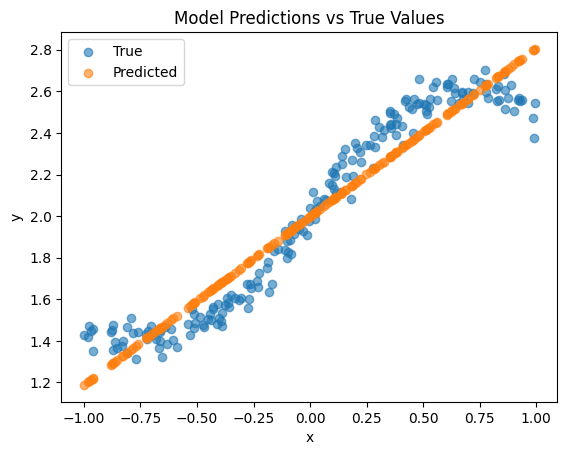

In [7]:
import matplotlib.pyplot as plt

y_pred = model.predict(x_test)

plt.scatter(x_test, y_test, label='True', alpha=0.6)
plt.scatter(x_test, y_pred, label='Predicted', alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Model Predictions vs True Values')
plt.legend()
plt.show()


In [7]:
#http://localhost:6006

In [8]:
%tensorboard --logdir logs/

A brief overview of the visualizations created in this example and the dashboards (tabs in top navigation bar) where they can be found:

* Scalars show how the loss and metrics change with every epoch. You can use them to also track training speed, learning rate, and other scalar values. Scalars can be found in the Time Series or Scalars dashboards.
* Graphs help you visualize your model. In this case, the Keras graph of layers is shown which can help you ensure it is built correctly. Graphs can be found in the Graphs dashboard.
* Histograms and Distributions show the distribution of a Tensor over time. This can be useful to visualize weights and biases and verify that they are changing in an expected way. Histograms can be found in the Time Series or Histograms dashboards. Distributions can be found in the Distributions dashboard.

Breakdown of the Debugger Interface
The Debugger Dashboard on the Tensorboard consists of five main components:

* __Alerts:__ This top-left section contains a list of alert events detected by the debugger in the debug data from the instrumented TensorFlow program. Each alert indicates a certain anomaly that warrants attention. In our case, this section highlights 499 NaN/∞ events with a salient pink-red color. This confirms our suspicion that the model fails to learn because of the presence of NaNs and/or infinities in its internal tensor values.
* __Python Execution Timeline:__ This is the upper half of the top-middle section. It presents the full history of the eager execution of ops and graphs. Each box of the timeline is marked by the initial letter of the op or graph’s name. We can navigate this timeline by using the navigation buttons and the scrollbar above the timeline.
* __Graph Execution:__ Located at the top-right corner of the GUI, this section will be central to our debugging task. It contains a history of all the floating-type tensors computed inside graphs, i.e., the ones compiled by @tf-functions.
* __Stack Trace:__ The bottom-right section, shows the stack trace of the creation of every single operation on the graph.
* __Source Code:__ The bottom-left section, highlights the source code corresponding to each operation on the graph.
